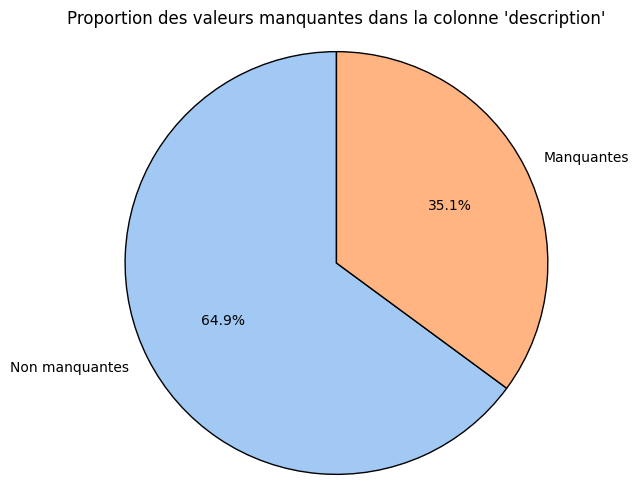

C:\Users\user\AppData\Local\Temp\ipykernel_68428\1313971454.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


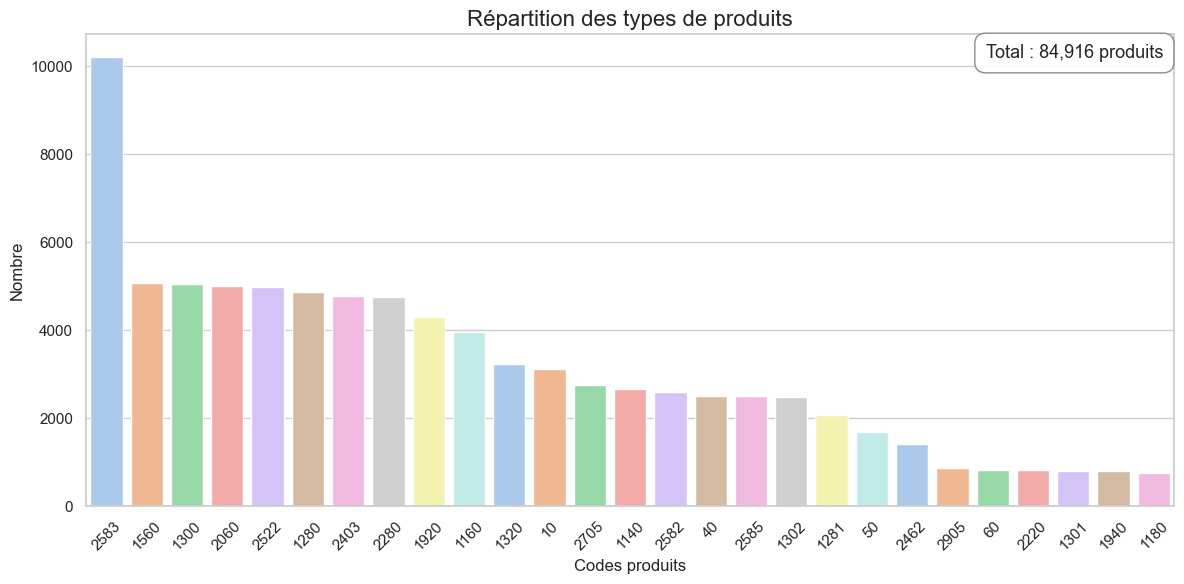

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv("..\..\Dataset\X_train.csv")

if 'Unnamed: 0' in data.columns:
    data = data.drop(columns='Unnamed: 0')

target = pd.read_csv("..\..\Dataset\Y_train.csv")

if 'Unnamed: 0' in target.columns:
    target = target.drop(columns='Unnamed: 0')


total = data.shape[0]
data['description'].isna().sum()/total

# Calcul des proportions

missing = data['description'].isna().sum()
not_missing = total - missing

# Données pour le camembert
labels = ['Non manquantes', 'Manquantes']
sizes = [not_missing, missing]
colors = sns.color_palette("pastel")[0:2]

# Création du camembert
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)
plt.title("Proportion des valeurs manquantes dans la colonne 'description'")
plt.axis('equal')  # pour un cercle parfait
plt.show()


# Taille et style du graphique
# Taille et style
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Histogramme
ax = sns.countplot(
    data=target,
    x="prdtypecode",
    palette="pastel",
    order=target["prdtypecode"].value_counts().index
)

# Titre et axes
plt.title("Répartition des types de produits", fontsize=16)
plt.xlabel("Codes produits", fontsize=12)
plt.ylabel("Nombre", fontsize=12)
plt.xticks(rotation=45)

# 🔷 Ajout d’un encart en haut à droite
total_count = len(target)
plt.text(
    0.99, 0.95,  # Position relative dans la figure (axe X, Y entre 0 et 1)
    f"Total : {total_count:,} produits",
    fontsize=13,
    transform=plt.gca().transAxes,
    ha='right',
    bbox=dict(boxstyle="round,pad=0.6", edgecolor="gray", facecolor="white", alpha=0.9)
)

plt.tight_layout()
plt.show()



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


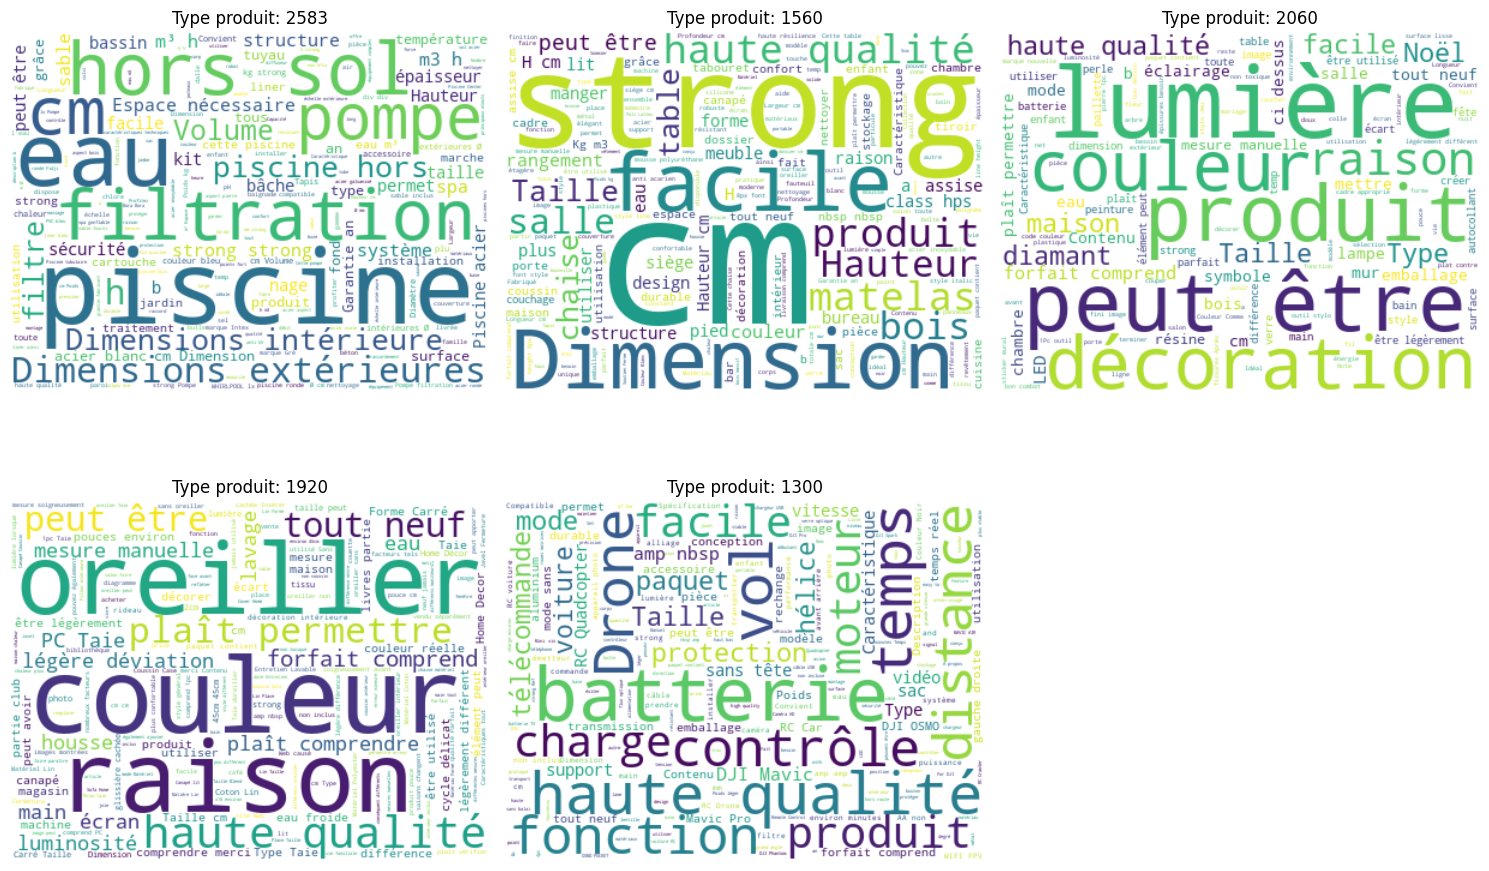

In [7]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

df_parc = pd.read_parquet(r"..\..\Dataset2\df.parquet")

# Télécharger les stopwords français (une seule fois)
nltk.download('stopwords')

# Charger stopwords français
stopwords_fr = set(stopwords.words('french'))

# Nettoyer NaN
df_clean = df_parc.dropna(subset=['description'])

# Top 5 types produits
top5_types = df_clean['prdtypecode'].value_counts().head(5).index.tolist()

# Filtrer uniquement top 5
df_top5 = df_clean[df_clean['prdtypecode'].isin(top5_types)]


extra_stopwords = {"li", "x", "br", "p", "span", "ul"}
stopwords_fr.update(extra_stopwords)
# Préparer textes concaténés par type produit
texts = {}
for prd_type in top5_types:
    texts[prd_type] = " ".join(df_top5[df_top5['prdtypecode'] == prd_type]['description'])

# Affichage nuages de mots avec stopwords français
plt.figure(figsize=(15,10))
for i, (prd_type, text) in enumerate(texts.items(), 1):
    wc = WordCloud(width=400, height=300, background_color='white', stopwords=stopwords_fr).generate(text)
    plt.subplot(2, 3, i)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Type produit: {prd_type}")

plt.tight_layout()
plt.show()
